In [1]:
!pip install transformers accelerate datasets torch scikit-learn emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=0a1d95fe5e8e8ab9d8a0dc9dfe60cf80cd35a3602f0d499083ae08dde920a87e
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [3]:
import pandas as pd
import numpy as np
import torch
import csv
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

data = pd.read_csv('combined_data.csv')

X = data['text_without_emoji'].tolist()
y = data['emoji_label'].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# make sure this is 43 emojis
print(f'Total number of unique emoji classes: {len(label_encoder.classes_)}')

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=12, stratify=y_encoded
)

train_df = pd.DataFrame({'text': X_train, 'label': y_train_enc})
test_df = pd.DataFrame({'text': X_test, 'label': y_test_enc})
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', use_fast=True)

def preprocess_text(text):
    new_text = []
    for t in str(text).split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

def tokenize_function(examples):
    processed_texts = [preprocess_text(t) for t in examples['text']]
    return tokenizer(processed_texts, truncation=True, padding='max_length', max_length=64)

tokenized_train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

tokenized_test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/bertweet-base',
    num_labels=len(label_encoder.classes_),
    hidden_dropout_prob=0.2,
)

training_args = TrainingArguments(
    output_dir='./results/bertweet_replicate',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=16,
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    max_grad_norm=1.0,
    optim='adamw_torch',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    weighted_f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

Total number of unique emoji classes: 43


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/688056 [00:00<?, ? examples/s]

Map:   0%|          | 0/172015 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3671741156.py:92: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [4]:
trainer.train()

results = trainer.evaluate()
print(results)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,2.759200,2.723846,0.258913,0.241744
2,2.626100,2.657709,0.275592,0.263497
3,2.606100,2.638935,0.281272,0.270928


{'eval_loss': 2.6389353275299072, 'eval_accuracy': 0.28127198209458476, 'eval_weighted_f1': 0.27092753053160745, 'eval_runtime': 166.413, 'eval_samples_per_second': 1033.664, 'eval_steps_per_second': 64.604, 'epoch': 3.0}


In [15]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

pred_output = trainer.predict(tokenized_test_dataset)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)
classes = label_encoder.classes_

precisions, recalls, f1s, supports = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(classes))
)

df_metrics = pd.DataFrame({
    "emoji": classes,
    "precision": precisions,
    "recall": recalls,
    "f1": f1s,
    "support": supports
})

print(df_metrics)


                            emoji  precision    recall        f1  support
0   backhand_index_pointing_right   0.580420  0.621568  0.600289     4006
1                      check_mark   0.435217  0.414000  0.424343     4000
2               check_mark_button   0.465104  0.446500  0.455612     4000
3                      clown_face   0.276171  0.331667  0.301385     4001
4                         cooking   0.306862  0.554361  0.395049     4001
5                             egg   0.439711  0.456636  0.448014     4001
6                    enraged_face   0.298236  0.397250  0.340695     4000
7                            eyes   0.262183  0.201750  0.228031     4000
8         face_holding_back_tears   0.210752  0.270432  0.236891     4001
9              face_savoring_food   0.335740  0.372000  0.352941     4000
10      face_with_steam_from_nose   0.207829  0.146000  0.171512     4000
11         face_with_tears_of_joy   0.275193  0.258750  0.266718     4000
12                   fearful_face   0.

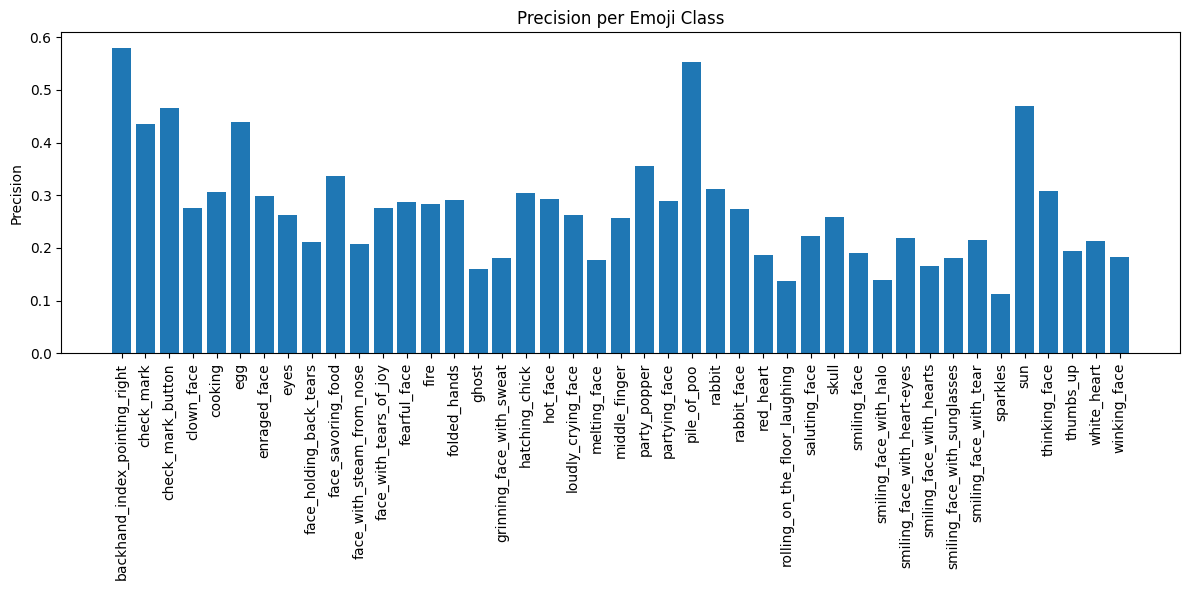

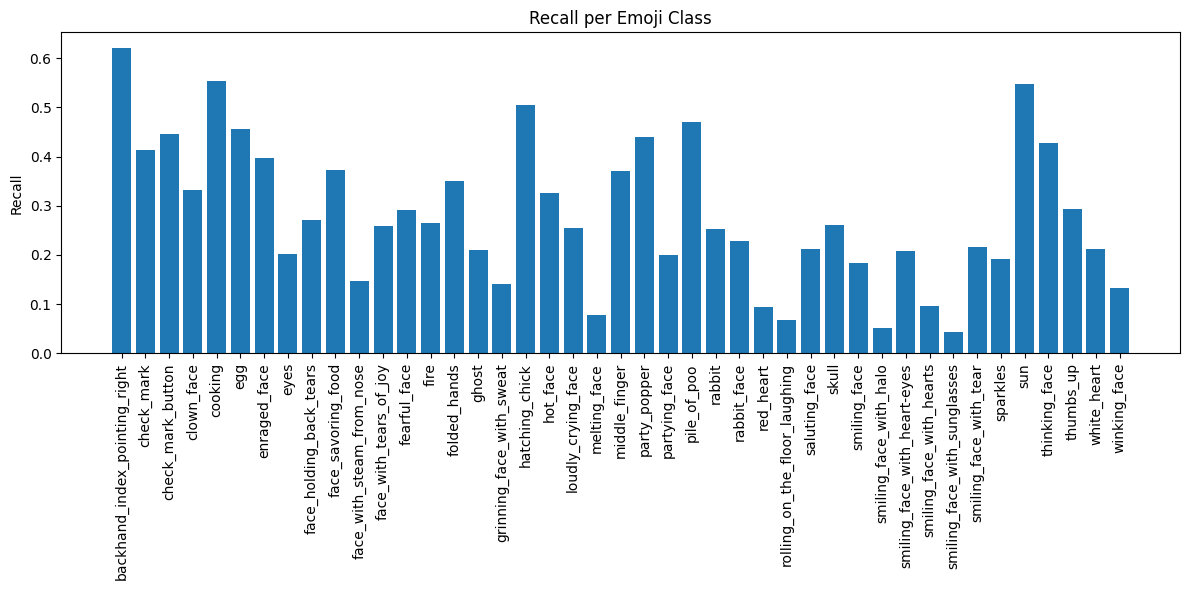

In [18]:
x = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(x, precisions)
plt.xticks(x, classes, rotation=90)
plt.ylabel("Precision")
plt.title("Precision per Emoji Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(x, recalls)
plt.xticks(x, classes, rotation=90)
plt.ylabel("Recall")
plt.title("Recall per Emoji Class")
plt.tight_layout()
plt.show()
